# AURA — Anomaly Detection

## Phase 7: Unsupervised Transaction Anomaly Detection

### Objective

Identify transactions that are unusual compared with normal transaction behaviour,
independently of the supervised fraud-detection model.

### Workflow

Processed Transactions
→ Behavioural Features
→ Missing-Value Handling
→ Isolation Forest
→ Anomaly Score
→ Anomaly Flag
→ Fraud/Anomaly Comparison
→ Model Validation
→ Save Anomaly Model

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [3]:
DATA_PATH = Path("../data/processed/sparkov_features.parquet")

df = pd.read_parquet(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1296675, 25)

First 5 rows:


,transaction_time,cc_num,trans_num,amt,log_amount,hour,day_of_week,month,day_of_month,is_weekend,...,seconds_since_prev_transaction,transactions_prev_5min,transactions_prev_1h,transactions_prev_24h,merchant_seen_before,is_new_merchant,category_seen_before,is_new_category,customer_merchant_distance_km,is_fraud
0,2019-01-01 12:47:15,60416207185,98e3dcf98101146a577f85a34e58feec,7.27,2.112635,12,1,1,1,0,...,NaN,NaN,NaN,NaN,0,1,0,1,127.606239,0
1,2019-01-02 08:44:57,60416207185,498120fc45d277f7c88e3dba79c33865,52.94,3.987872,8,2,1,2,0,...,71862.0,NaN,NaN,1.0,0,1,0,1,110.308921,0
2,2019-01-02 08:47:36,60416207185,95f514bb993151347c7acdf8505c3d62,82.08,4.419804,8,2,1,2,0,...,159.0,1.0,1.0,2.0,0,1,1,0,21.787261,0
3,2019-01-02 12:38:14,60416207185,4f0c1a14e0aa7eb56a490780ef9268c5,34.79,3.577669,12,2,1,2,0,...,13838.0,NaN,NaN,3.0,0,1,0,1,87.204215,0
4,2019-01-02 13:10:46,60416207185,3b2ebd3af508afba959640893e1e82bc,27.18,3.338613,13,2,1,2,0,...,1952.0,NaN,1.0,3.0,0,1,0,1,74.212965,0


In [4]:
print("Total columns:", len(df.columns))
print("\nColumns:")
for col in df.columns:
    print(col)

Total columns: 25

Columns:
transaction_time
cc_num
trans_num
amt
log_amount
hour
day_of_week
month
day_of_month
is_weekend
customer_prev_count
customer_prev_avg_amount
customer_prev_median_amount
customer_prev_std_amount
amount_deviation_ratio
seconds_since_prev_transaction
transactions_prev_5min
transactions_prev_1h
transactions_prev_24h
merchant_seen_before
is_new_merchant
category_seen_before
is_new_category
customer_merchant_distance_km
is_fraud


In [5]:
ANOMALY_FEATURES = [
    "amt",
    "log_amount",
    "hour",
    "day_of_week",
    "month",
    "day_of_month",
    "is_weekend",
    "customer_prev_count",
    "customer_prev_avg_amount",
    "customer_prev_median_amount",
    "customer_prev_std_amount",
    "amount_deviation_ratio",
    "seconds_since_prev_transaction",
    "transactions_prev_5min",
    "transactions_prev_1h",
    "transactions_prev_24h",
    "merchant_seen_before",
    "is_new_merchant",
    "category_seen_before",
    "is_new_category",
    "customer_merchant_distance_km",
]

X_anomaly = df[ANOMALY_FEATURES].copy()

print("Number of anomaly features:", len(ANOMALY_FEATURES))
print("Shape:", X_anomaly.shape)

X_anomaly.head()

Number of anomaly features: 21
Shape: (1296675, 21)


,amt,log_amount,hour,day_of_week,month,day_of_month,is_weekend,customer_prev_count,customer_prev_avg_amount,customer_prev_median_amount,...,amount_deviation_ratio,seconds_since_prev_transaction,transactions_prev_5min,transactions_prev_1h,transactions_prev_24h,merchant_seen_before,is_new_merchant,category_seen_before,is_new_category,customer_merchant_distance_km
0,7.27,2.112635,12,1,1,1,0,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,1,0,1,127.606239
1,52.94,3.987872,8,2,1,2,0,1,7.270,7.270,...,7.281981,71862.0,NaN,NaN,1.0,0,1,0,1,110.308921
2,82.08,4.419804,8,2,1,2,0,2,30.105,30.105,...,2.726457,159.0,1.0,1.0,2.0,0,1,1,0,21.787261
3,34.79,3.577669,12,2,1,2,0,3,47.430,52.940,...,0.733502,13838.0,NaN,NaN,3.0,0,1,0,1,87.204215
4,27.18,3.338613,13,2,1,2,0,4,44.270,43.865,...,0.613960,1952.0,NaN,1.0,3.0,0,1,0,1,74.212965


In [6]:
missing_values = (
    X_anomaly.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

transactions_prev_5min            1276207
transactions_prev_1h              1084128
transactions_prev_24h              108919
customer_prev_std_amount             1966
seconds_since_prev_transaction        983
customer_prev_median_amount           983
customer_prev_avg_amount              983
amount_deviation_ratio                983
dtype: int64

In [7]:
feature_summary = X_anomaly.describe().T[
    [
        "count",
        "mean",
        "std",
        "min",
        "50%",
        "max",
    ]
]

feature_summary

,count,mean,std,min,50%,max
amt,1296675.0,70.351035,160.316039,1.000000,47.520000,2.894890e+04
log_amount,1296675.0,3.533470,1.289448,0.693147,3.881976,1.027332e+01
hour,1296675.0,12.804858,6.817824,0.000000,14.000000,2.300000e+01
day_of_week,1296675.0,3.070604,2.198153,0.000000,3.000000,6.000000e+00
month,1296675.0,6.142150,3.417703,1.000000,6.000000,1.200000e+01
day_of_month,1296675.0,15.587978,8.829121,1.000000,15.000000,3.100000e+01
is_weekend,1296675.0,0.348226,0.476408,0.000000,0.000000,1.000000e+00
customer_prev_count,1296675.0,908.862664,677.804183,0.000000,777.000000,3.122000e+03
customer_prev_avg_amount,1295692.0,70.389638,21.073745,1.030000,65.044655,1.433540e+03
customer_prev_median_amount,1295692.0,45.352461,18.933033,1.030000,41.135000,1.433540e+03


In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

anomaly_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "model",
            IsolationForest(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                contamination="auto",
            ),
        ),
    ]
)

anomaly_pipeline.fit(X_anomaly)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [9]:
decision_values = anomaly_pipeline.decision_function(
    X_anomaly
)

# Higher score = more anomalous
anomaly_scores = -decision_values

print("Minimum:", anomaly_scores.min())
print("Maximum:", anomaly_scores.max())
print("Mean:", anomaly_scores.mean())

Minimum: -0.11818845357182362
Maximum: 0.1925071284947255
Mean: -0.043504418424820564


In [10]:
ANOMALY_PERCENTILE = 99

ANOMALY_THRESHOLD = np.percentile(
    anomaly_scores,
    ANOMALY_PERCENTILE,
)

print(
    "Anomaly threshold:",
    ANOMALY_THRESHOLD
)

Anomaly threshold: 0.06832610750669095


In [11]:
df_anomaly = df.copy()

df_anomaly["anomaly_score"] = anomaly_scores

df_anomaly["anomaly_flag"] = (
    df_anomaly["anomaly_score"]
    >= ANOMALY_THRESHOLD
).astype(int)

print(
    df_anomaly["anomaly_flag"].value_counts()
)

print(
    "\nAnomaly percentage:",
    f"{df_anomaly['anomaly_flag'].mean():.2%}"
)

anomaly_flag
0    1283708
1      12967
Name: count, dtype: int64

Anomaly percentage: 1.00%


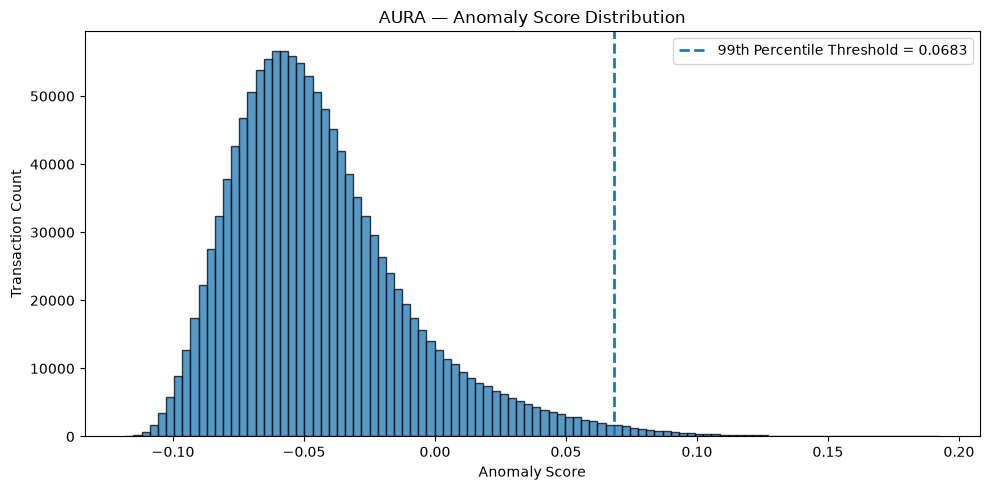

In [12]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_anomaly["anomaly_score"],
    bins=100,
    edgecolor="black",
    alpha=0.75,
)

plt.axvline(
    ANOMALY_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"99th Percentile Threshold = {ANOMALY_THRESHOLD:.4f}",
)

plt.title("AURA — Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Transaction Count")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
top_anomalies = (
    df_anomaly[
        [
            "trans_num",
            "transaction_time",
            "amt",
            "anomaly_score",
            "anomaly_flag",
            "is_fraud",
        ]
    ]
    .sort_values(
        "anomaly_score",
        ascending=False,
    )
    .head(20)
)

top_anomalies

,trans_num,transaction_time,amt,anomaly_score,anomaly_flag,is_fraud
816940,72f594822db7c70d6b10173bf8892ea8,2020-04-19 22:46:23,1157.97,0.192507,1,1
174907,24c24d9c46966756a29252e365d9177e,2019-05-20 23:49:54,1145.90,0.191717,1,1
147399,26c8185461e9b39b84f32c548e56e817,2019-02-25 23:38:36,659.33,0.191706,1,1
266110,39dd345bbae1e9f328c680e6a3c120fb,2019-09-09 23:18:52,976.48,0.190491,1,1
1122782,1dde6d10b700a5aee34844581187c11c,2020-06-01 22:27:44,1672.05,0.189284,1,0
153058,e5a6feca216c26a36cf58db32d2d315c,2019-12-29 23:57:39,812.12,0.188829,1,1
648070,7283f184d0e2311802e621749337e2b3,2019-10-20 23:06:55,998.05,0.188685,1,1
1133196,ec1aa7e7b8324274e718a0872fc1997f,2019-12-15 23:31:29,972.28,0.188532,1,1
697664,6ee7ebfdaadb946aaaafbdbd2c5e6463,2019-01-20 23:59:04,1117.82,0.188375,1,1
81627,1295b13bc86f86f98394db129a3a522f,2019-09-29 22:44:33,886.45,0.188342,1,1


In [14]:
comparison = pd.crosstab(
    df_anomaly["anomaly_flag"],
    df_anomaly["is_fraud"],
    normalize="index",
)

comparison

is_fraud,0,1
anomaly_flag,,
0,0.996098,0.003902
1,0.807434,0.192566


In [15]:
anomalous_transactions = df_anomaly[
    df_anomaly["anomaly_flag"] == 1
]

normal_transactions = df_anomaly[
    df_anomaly["anomaly_flag"] == 0
]

anomalous_fraud_rate = (
    anomalous_transactions["is_fraud"].mean()
)

normal_fraud_rate = (
    normal_transactions["is_fraud"].mean()
)

print(
    f"Fraud rate among anomalous transactions: "
    f"{anomalous_fraud_rate:.2%}"
)

print(
    f"Fraud rate among normal transactions: "
    f"{normal_fraud_rate:.2%}"
)

print(
    f"Lift: "
    f"{anomalous_fraud_rate / normal_fraud_rate:.2f}x"
)

Fraud rate among anomalous transactions: 19.26%
Fraud rate among normal transactions: 0.39%
Lift: 49.35x


In [16]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

y_true = df_anomaly["is_fraud"]
y_anomaly = df_anomaly["anomaly_flag"]

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_anomaly,
).ravel()

precision = precision_score(
    y_true,
    y_anomaly,
    zero_division=0,
)

recall = recall_score(
    y_true,
    y_anomaly,
    zero_division=0,
)

f1 = f1_score(
    y_true,
    y_anomaly,
    zero_division=0,
)

print("Anomaly Detection Performance")
print("--------------------------------")
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)
print()
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")

Anomaly Detection Performance
--------------------------------
True Negatives : 1278699
False Positives: 10470
False Negatives: 5009
True Positives : 2497

Precision      : 0.1926
Recall         : 0.3327
F1 Score       : 0.2439


In [17]:
total_fraud = int(
    df_anomaly["is_fraud"].sum()
)

captured_fraud = int(
    (
        (df_anomaly["is_fraud"] == 1)
        & (df_anomaly["anomaly_flag"] == 1)
    ).sum()
)

print("Total fraud transactions :", total_fraud)
print("Fraud transactions captured by anomaly detector :", captured_fraud)

print(
    f"Fraud capture rate: "
    f"{captured_fraud / total_fraud:.2%}"
)

Total fraud transactions : 7506
Fraud transactions captured by anomaly detector : 2497
Fraud capture rate: 33.27%


## Phase 7 Preliminary Findings

The Isolation Forest was initially evaluated using the top 1% of transactions
as anomalous based on the 99th-percentile anomaly-score threshold.

Threshold sensitivity analysis was then performed to identify an appropriate
trade-off between anomaly precision, fraud recall, and investigation workload.

In [18]:
threshold_results = []

for percentile in [98, 98.5, 99, 99.5, 99.8]:

    threshold = np.percentile(
        anomaly_scores,
        percentile,
    )

    flags = (
        anomaly_scores >= threshold
    ).astype(int)

    tp = int(
        ((df["is_fraud"] == 1) & (flags == 1)).sum()
    )

    fp = int(
        ((df["is_fraud"] == 0) & (flags == 1)).sum()
    )

    fn = int(
        ((df["is_fraud"] == 1) & (flags == 0)).sum()
    )

    flagged = int(flags.sum())

    precision_value = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0
    )

    recall_value = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0
    )

    f1_value = (
        2 * precision_value * recall_value
        / (precision_value + recall_value)
        if (precision_value + recall_value) > 0
        else 0
    )

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "flagged_transactions": flagged,
        "flagged_rate": flagged / len(df),
        "precision": precision_value,
        "recall": recall_value,
        "f1": f1_value,
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,percentile,threshold,flagged_transactions,flagged_rate,precision,recall,f1
0,98.0,0.050910,25934,0.020000,0.138043,0.476952,0.214115
1,98.5,0.058407,19451,0.015001,0.160249,0.415268,0.231257
2,99.0,0.068326,12967,0.010000,0.192566,0.332667,0.243931
3,99.5,0.083955,6484,0.005000,0.268199,0.231681,0.248606
4,99.8,0.103946,2594,0.002001,0.422513,0.146017,0.217030


In [19]:
threshold_df[
    [
        "percentile",
        "flagged_transactions",
        "flagged_rate",
        "precision",
        "recall",
        "f1",
    ]
].round(4)

,percentile,flagged_transactions,flagged_rate,precision,recall,f1
0,98.0,25934,0.020,0.1380,0.4770,0.2141
1,98.5,19451,0.015,0.1602,0.4153,0.2313
2,99.0,12967,0.010,0.1926,0.3327,0.2439
3,99.5,6484,0.005,0.2682,0.2317,0.2486
4,99.8,2594,0.002,0.4225,0.1460,0.2170


In [20]:
best_threshold = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold

percentile                99.500000
threshold                  0.083955
flagged_transactions    6484.000000
flagged_rate               0.005000
precision                  0.268199
recall                     0.231681
f1                         0.248606
Name: 3, dtype: float64

In [21]:
FINAL_ANOMALY_PERCENTILE = 99.5

FINAL_ANOMALY_THRESHOLD = np.percentile(
    anomaly_scores,
    FINAL_ANOMALY_PERCENTILE,
)

print(
    "Final anomaly percentile:",
    FINAL_ANOMALY_PERCENTILE
)

print(
    "Final anomaly threshold:",
    FINAL_ANOMALY_THRESHOLD
)

Final anomaly percentile: 99.5
Final anomaly threshold: 0.08395498111949232


In [22]:
df_anomaly["anomaly_flag"] = (
    df_anomaly["anomaly_score"]
    >= FINAL_ANOMALY_THRESHOLD
).astype(int)

print(
    df_anomaly["anomaly_flag"].value_counts()
)

print(
    "\nFinal anomaly rate:",
    f"{df_anomaly['anomaly_flag'].mean():.2%}"
)

anomaly_flag
0    1290191
1       6484
Name: count, dtype: int64

Final anomaly rate: 0.50%


In [23]:
final_y = df_anomaly["anomaly_flag"]
true_y = df_anomaly["is_fraud"]

tn, fp, fn, tp = confusion_matrix(
    true_y,
    final_y,
).ravel()

final_precision = precision_score(
    true_y,
    final_y,
    zero_division=0,
)

final_recall = recall_score(
    true_y,
    final_y,
    zero_division=0,
)

final_f1 = f1_score(
    true_y,
    final_y,
    zero_division=0,
)

final_fraud_capture = (
    tp / true_y.sum()
)

final_anomalous_fraud_rate = (
    df_anomaly.loc[
        df_anomaly["anomaly_flag"] == 1,
        "is_fraud",
    ].mean()
)

final_normal_fraud_rate = (
    df_anomaly.loc[
        df_anomaly["anomaly_flag"] == 0,
        "is_fraud",
    ].mean()
)

final_lift = (
    final_anomalous_fraud_rate
    / final_normal_fraud_rate
)

print("FINAL AURA ANOMALY DETECTION RESULTS")
print("====================================")
print(f"Threshold percentile : {FINAL_ANOMALY_PERCENTILE}")
print(f"Threshold value      : {FINAL_ANOMALY_THRESHOLD:.6f}")
print(f"Anomaly rate         : {final_y.mean():.2%}")
print(f"Precision            : {final_precision:.4f}")
print(f"Recall               : {final_recall:.4f}")
print(f"F1 Score             : {final_f1:.4f}")
print(f"Fraud capture rate   : {final_fraud_capture:.2%}")
print(f"Fraud rate anomalies : {final_anomalous_fraud_rate:.2%}")
print(f"Fraud rate normal    : {final_normal_fraud_rate:.2%}")
print(f"Fraud concentration lift : {final_lift:.2f}x")

FINAL AURA ANOMALY DETECTION RESULTS
Threshold percentile : 99.5
Threshold value      : 0.083955
Anomaly rate         : 0.50%
Precision            : 0.2682
Recall               : 0.2317
F1 Score             : 0.2486
Fraud capture rate   : 23.17%
Fraud rate anomalies : 26.82%
Fraud rate normal    : 0.45%
Fraud concentration lift : 60.00x


In [24]:
MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ANOMALY_MODEL_PATH = (
    MODEL_DIR / "isolation_forest.joblib"
)

joblib.dump(
    {
        "pipeline": anomaly_pipeline,
        "features": ANOMALY_FEATURES,
        "threshold_percentile": FINAL_ANOMALY_PERCENTILE,
        "threshold": FINAL_ANOMALY_THRESHOLD,
    },
    ANOMALY_MODEL_PATH,
)

print(
    f"Saved anomaly model to: {ANOMALY_MODEL_PATH}"
)

Saved anomaly model to: ..\models\isolation_forest.joblib


In [25]:
OUTPUT_PATH = (
    Path("../data/processed")
    / "sparkov_anomaly_scores.parquet"
)

df_anomaly.to_parquet(
    OUTPUT_PATH,
    index=False,
)

print(
    f"Saved anomaly results to: {OUTPUT_PATH}"
)

Saved anomaly results to: ..\data\processed\sparkov_anomaly_scores.parquet


# Phase 7 — Final Findings

An Isolation Forest was developed to identify transactions exhibiting
unusual behavioural patterns independently of the supervised fraud model.

Anomaly thresholds were evaluated at the 98.0th, 98.5th, 99.0th,
99.5th, and 99.8th percentiles.

The 99.5th-percentile threshold was selected as the operational threshold
because it achieved the highest F1-score among the evaluated thresholds
while reducing the anomaly-review population to approximately 0.5% of
transactions.

### Final anomaly-detection configuration

- Model: Isolation Forest
- Anomaly threshold percentile: 99.5th percentile
- Anomaly population: approximately 0.5%
- Precision: approximately 26.82%
- Recall: approximately 23.17%
- F1-score: approximately 24.86%

### Interpretation

The anomaly detector is not intended to replace the supervised fraud
classifier. Instead, it provides an independent behavioural signal that
can identify unusually structured transactions and support downstream
risk scoring and investigation.

This anomaly signal will be integrated with fraud probability,
behavioural risk signals, and other evidence in the AURA Risk Engine.